**Run note:** execute this notebook's first setup/code cell before any later cells. Each notebook is designed to run independently and re-detect the dataset path on its own.

# 02 â€” Data Inspection & Verification

Load all splits, verify files, inspect raw samples, check class balance, and identify data quality issues.

In [2]:
import os
import json
import hashlib
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

ON_KAGGLE = Path("/kaggle/input").is_dir()
JSONL_CANDIDATES = {
    "train": ["train.jsonl"],
    "dev": ["dev.jsonl", "dev_seen.jsonl", "dev_unseen.jsonl"],
    "test": ["test.jsonl", "test_seen.jsonl", "test_unseen.jsonl"],
}
IMAGE_DIR_CANDIDATES = ("img", "images")


def _has_image_dir(path: Path) -> bool:
    return any((path / name).is_dir() for name in IMAGE_DIR_CANDIDATES)


def _has_any_jsonl(path: Path, names) -> bool:
    return any((path / name).is_file() for name in names)


def _looks_like_dataset_root(path: Path) -> bool:
    return path.is_dir() and _has_image_dir(path) and _has_any_jsonl(path, JSONL_CANDIDATES["train"])


def detect_data_dir():
    for env_name in ("KAGGLE_DATA_DIR", "META_HATEFUL_MEME_DATA_DIR"):
        env_dir = os.environ.get(env_name, "").strip()
        if env_dir and _looks_like_dataset_root(Path(env_dir)):
            return Path(env_dir), f"env:{env_name}"

    kaggle_input = Path("/kaggle/input")
    default_candidate = kaggle_input / "meta-hateful-meme-detection" / "data"
    if _looks_like_dataset_root(default_candidate):
        return default_candidate, "default:/kaggle/input/meta-hateful-meme-detection/data"

    if ON_KAGGLE:
        for train_jsonl in sorted(kaggle_input.rglob("train.jsonl")):
            candidate = train_jsonl.parent
            if _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

        for candidate in sorted(kaggle_input.rglob("*")):
            if candidate.is_dir() and _looks_like_dataset_root(candidate):
                return candidate, f"auto:{candidate}"

    for candidate in (Path.cwd() / "data", Path.cwd().parent / "data", Path.cwd(), Path.cwd().parent):
        if _looks_like_dataset_root(candidate):
            return candidate, f"local:{candidate}"

    return None, "not-found"


def resolve_split(base_dir, names):
    base_dir = Path(base_dir)
    for name in names:
        path = base_dir / name
        if path.is_file():
            return path
    for name in names:
        matches = sorted(base_dir.rglob(name))
        if matches:
            return matches[0]
    return None


DATA_DIR, data_source = detect_data_dir()
if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Set KAGGLE_DATA_DIR or META_HATEFUL_MEME_DATA_DIR to the folder containing train.jsonl and img/."
    )

IMG_DIR = next((DATA_DIR / name for name in IMAGE_DIR_CANDIDATES if (DATA_DIR / name).is_dir()), None)
TRAIN_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["train"])
DEV_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["dev"])
TEST_PATH = resolve_split(DATA_DIR, JSONL_CANDIDATES["test"])
OUTPUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if TRAIN_PATH is None or DEV_PATH is None or TEST_PATH is None:
    raise FileNotFoundError(f"Expected train/dev/test splits under {DATA_DIR}")

DATA_DIR = str(DATA_DIR)
IMG_DIR = str(IMG_DIR) if IMG_DIR is not None else None
TRAIN_PATH = str(TRAIN_PATH)
DEV_PATH = str(DEV_PATH)
TEST_PATH = str(TEST_PATH)
OUTPUT_DIR = str(OUTPUT_DIR)

print(f"Using DATA_DIR : {DATA_DIR}")
print(f"Using IMG_DIR  : {IMG_DIR}")
print(f"Using source   : {data_source}")
print(f"Output dir     : {OUTPUT_DIR}")


def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return pd.DataFrame([json.loads(l) for l in f])


train = load_jsonl(TRAIN_PATH)
dev = load_jsonl(DEV_PATH)
test = load_jsonl(TEST_PATH)

print(f"Train: {len(train):,} samples")
print(f"Dev  : {len(dev):,} samples")
print(f"Test : {len(test):,} samples")
print(f"\nTrain columns: {list(train.columns)}")
train.head(3)

Using DATA_DIR : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Using IMG_DIR  : /kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data/img
Using source   : auto:/kaggle/input/datasets/muddybuddy/meta-hateful-meme-detection/data
Output dir     : /kaggle/working
Train: 8,500 samples
Dev  : 500 samples
Test : 1,000 samples

Train columns: ['id', 'img', 'label', 'text']


,id,img,label,text
0,42953,img/42953.png,0,its their character not their color that matters
1,23058,img/23058.png,0,don't be afraid to love again everyone is not ...
2,13894,img/13894.png,0,putting bows on your pet


In [3]:
from pathlib import Path


def resolve_image_path(data_dir, image_ref):
    data_dir = Path(data_dir)
    image_ref = Path(str(image_ref))

    candidates = []
    if image_ref.is_absolute():
        candidates.append(image_ref)

    candidates.extend([
        data_dir / image_ref,
        data_dir.parent / image_ref,
    ])

    if image_ref.parts:
        if image_ref.parts[0] in {"img", "images"} and len(image_ref.parts) > 1:
            stripped = Path(*image_ref.parts[1:])
            candidates.extend([
                data_dir / stripped,
                data_dir.parent / stripped,
            ])
        elif image_ref.parts[0] not in {"img", "images"}:
            candidates.extend([
                data_dir / "img" / image_ref,
                data_dir / "images" / image_ref,
                data_dir.parent / "img" / image_ref,
                data_dir.parent / "images" / image_ref,
            ])

    seen = set()
    for candidate in candidates:
        key = str(candidate)
        if key in seen:
            continue
        seen.add(key)
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f"Could not find image '{image_ref}' relative to {data_dir}")

In [4]:
# â”€â”€ Class balance per split â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for name, df in [("Train", train), ("Dev", dev)]:
    counts = df["label"].value_counts().sort_index()
    total  = len(df)
    print(f"{name}:")
    for label, count in counts.items():
        tag = "hateful" if label == 1 else "non-hateful"
        print(f"  label={label} ({tag}): {count:,}  ({100*count/total:.1f}%)")
    print()

Train:
  label=0 (non-hateful): 5,450  (64.1%)
  label=1 (hateful): 3,050  (35.9%)

Dev:
  label=0 (non-hateful): 250  (50.0%)
  label=1 (hateful): 250  (50.0%)



In [5]:
# â”€â”€ Image file existence check â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
all_data = pd.concat([train, dev, test], ignore_index=True)
missing, corrupted = [], []

for _, row in all_data.iterrows():
    img_path = os.path.join(DATA_DIR, row["img"])
    if not os.path.exists(img_path):
        missing.append(row["id"])
    else:
        try:
            Image.open(img_path).verify()
        except Exception:
            corrupted.append(row["id"])

print(f"Total samples checked : {len(all_data):,}")
print(f"Missing images        : {len(missing)}")
print(f"Corrupted images      : {len(corrupted)}")
if missing:
    print(f"  Missing IDs sample  : {missing[:10]}")

Total samples checked : 10,000
Missing images        : 0
Corrupted images      : 0


In [6]:
# â”€â”€ Check for duplicate or near-duplicate entries â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def md5(path):
    try:
        with open(path, "rb") as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

train["img_hash"] = train["img"].apply(
    lambda p: md5(os.path.join(DATA_DIR, p))
)
train["text_hash"] = train["text"].apply(lambda t: hashlib.md5(t.encode()).hexdigest())

dup_imgs  = train["img_hash"].duplicated().sum()
dup_texts = train["text_hash"].duplicated().sum()
print(f"Duplicate image files in train : {dup_imgs}")
print(f"Duplicate text entries in train: {dup_texts}")

# Check train/dev leakage
dev["img_hash"] = dev["img"].apply(lambda p: md5(os.path.join(DATA_DIR, p)))
overlap = set(train["img_hash"]) & set(dev["img_hash"])
print(f"Train/Dev image overlap        : {len(overlap)}")

Duplicate image files in train : 0
Duplicate text entries in train: 1428
Train/Dev image overlap        : 0


In [7]:
# â”€â”€ Missing or empty text fields â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
for name, df in [("Train", train), ("Dev", dev), ("Test", test)]:
    null_text  = df["text"].isna().sum()
    empty_text = (df["text"].str.strip() == "").sum()
    print(f"{name}: null_text={null_text}, empty_text={empty_text}")

Train: null_text=0, empty_text=0
Dev: null_text=0, empty_text=0
Test: null_text=0, empty_text=0


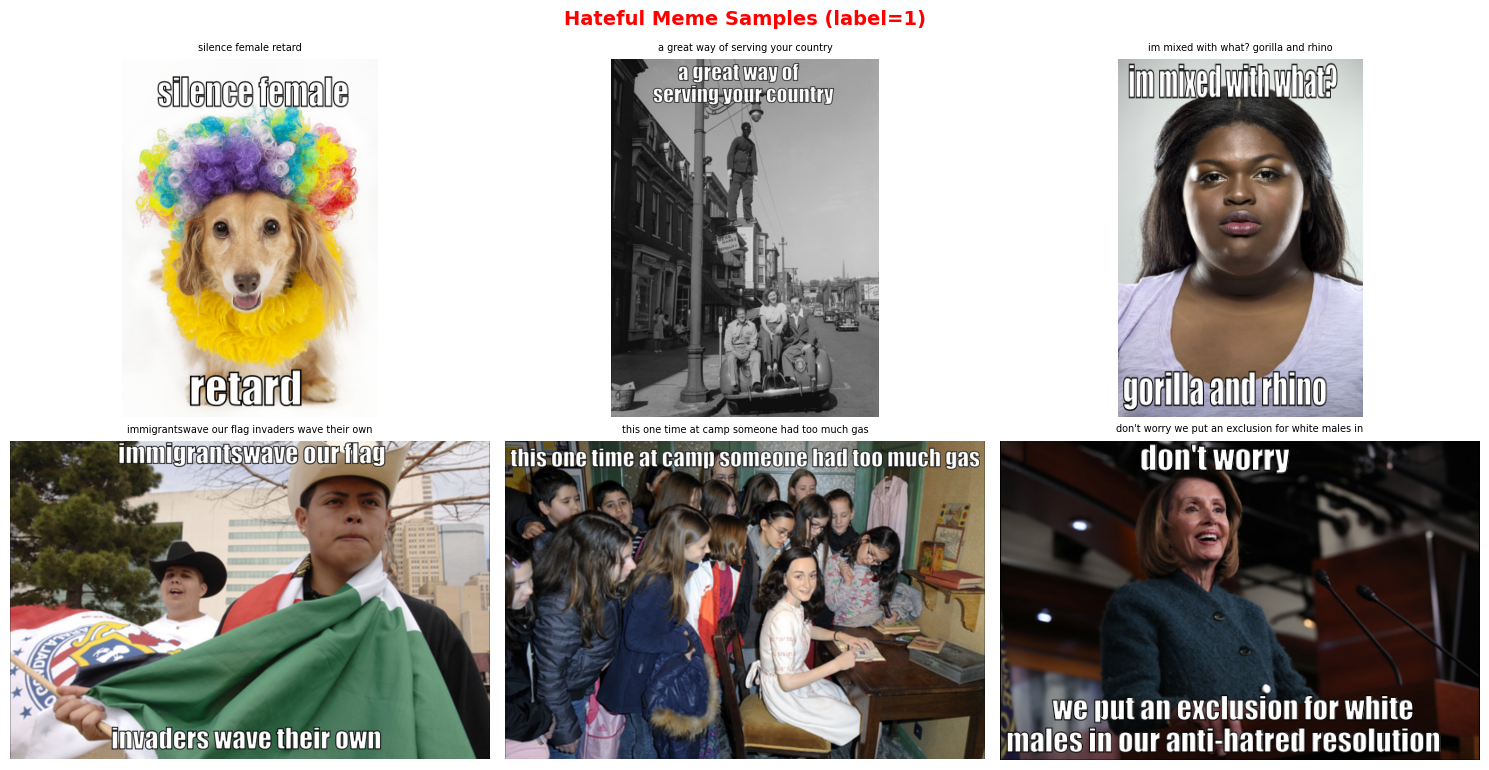

In [8]:
# â”€â”€ Random sample inspection â€” hateful examples â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import random
random.seed(42)

hateful_samples = train[train["label"] == 1].sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Hateful Meme Samples (label=1)", fontsize=14, fontweight="bold", color="red")

for ax, (_, row) in zip(axes.flat, hateful_samples.iterrows()):
    img_path = os.path.join(DATA_DIR, row["img"])
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, "[missing]", ha="center")
    ax.set_title(row["text"][:50], fontsize=7, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.show()

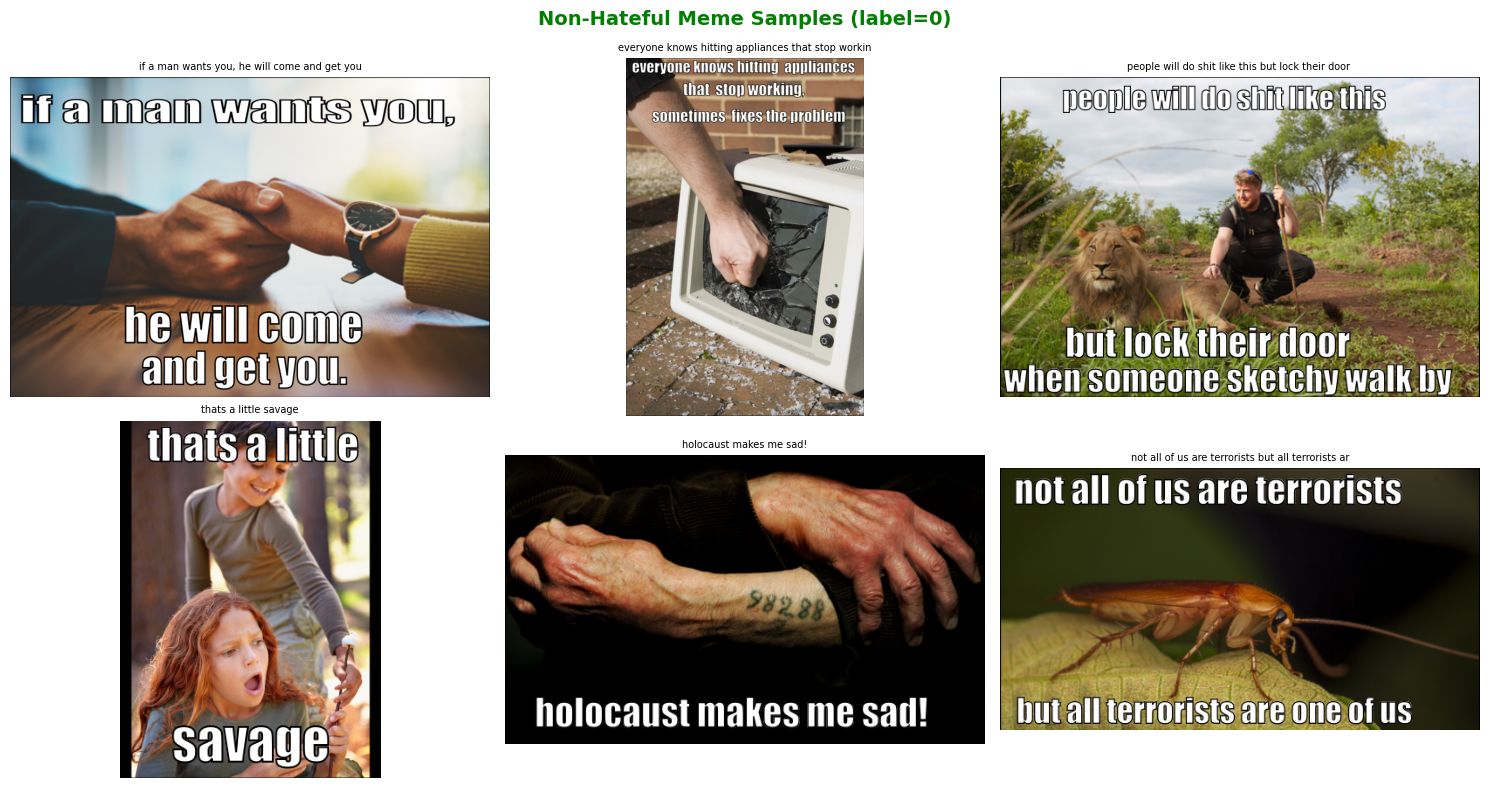

In [9]:
# â”€â”€ Random sample inspection â€” non-hateful examples â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
benign_samples = train[train["label"] == 0].sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Non-Hateful Meme Samples (label=0)", fontsize=14, fontweight="bold", color="green")

for ax, (_, row) in zip(axes.flat, benign_samples.iterrows()):
    img_path = os.path.join(DATA_DIR, row["img"])
    try:
        img = mpimg.imread(img_path)
        ax.imshow(img)
    except:
        ax.text(0.5, 0.5, "[missing]", ha="center")
    ax.set_title(row["text"][:50], fontsize=7, wrap=True)
    ax.axis("off")

plt.tight_layout()
plt.show()

Width   min: 247, max: 825, mean: 609
Height  min: 309, max: 804, mean: 527


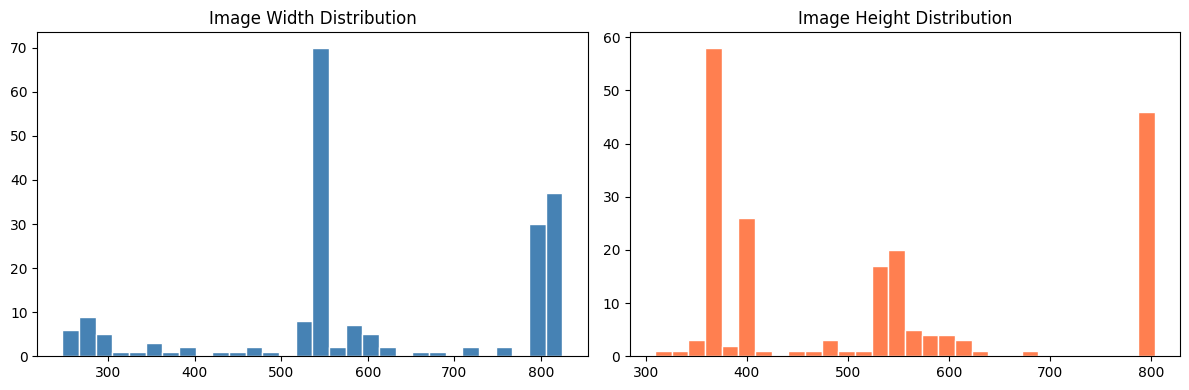

In [10]:
#  Image resolution analysis 
widths, heights = [], []
for _, row in train.sample(200, random_state=42).iterrows():
    try:
        img = Image.open(resolve_image_path(DATA_DIR, row["img"]))
        w, h = img.size
        widths.append(w)
        heights.append(h)
    except:
        pass

print(f"Width   min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}")
print(f"Height  min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(widths, bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Image Width Distribution")
axes[1].hist(heights, bins=30, color="coral", edgecolor="white")
axes[1].set_title("Image Height Distribution")
plt.tight_layout()
plt.show()

Text length by label:
        count   mean   std  min  25%   50%   75%   max
label                                                 
0      5450.0  11.15  6.56  1.0  7.0  10.0  14.0  69.0
1      3050.0  12.79  7.30  1.0  8.0  11.0  17.0  70.0


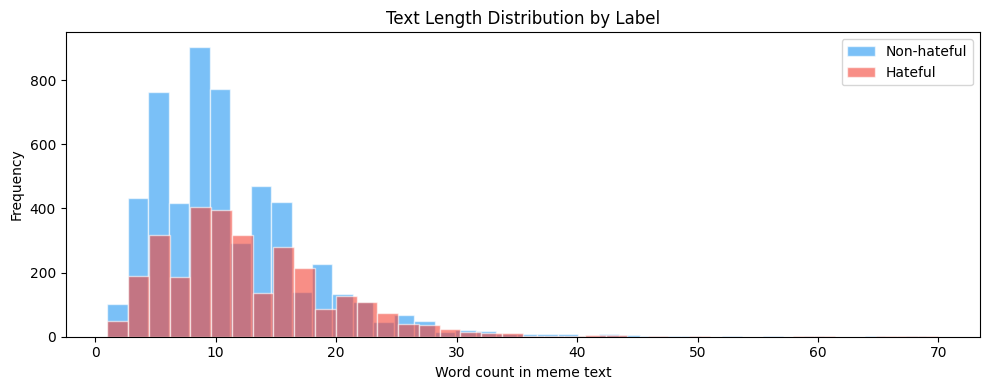

In [11]:
# â”€â”€ Modality-need analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Samples with very short text might rely more on image; very long text might be text-dominant
train["text_len"] = train["text"].str.split().str.len()

print("Text length by label:")
print(train.groupby("label")["text_len"].describe().round(2))

fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(0, "#2196F3", "Non-hateful"), (1, "#F44336", "Hateful")]:
    subset = train[train["label"] == label]["text_len"]
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor="white")
ax.set_xlabel("Word count in meme text")
ax.set_ylabel("Frequency")
ax.set_title("Text Length Distribution by Label")
ax.legend()
plt.tight_layout()
plt.show()